# Notebook 4: Quantum elementary cellular automata

## Importing relevant functions

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import random
import itertools

In [37]:
# From Notebook 1

from Functions_for_Notebook_1 import make_rule, make_rule_zero_condition, make_rule_symmetry #For making the rules

from Functions_for_Notebook_1 import dynamics, dynamics_reflection, dynamics_periodic #For the dynamics

from Functions_for_Notebook_1 import plot_grid #For the plotting

In [38]:
# From Notebook 2
from Functions_for_Notebook_2 import plot_grid_multiple, plot_multiple_cells, dynamics_initialandfinal #To grid multiple systems

from Functions_for_Notebook_2 import is_rule

from Functions_for_Notebook_2 import is_reversible, gardens_of_eden

In [39]:
# From Notebook 3
from Functions_for_Notebook_3 import vectorized_ic, next_state, markov_matrix, markov_matrix_mapping  # Describe evolutions with matrices

from Functions_for_Notebook_3 import probabilistic_dynamics, probabilistic_dynamics_initialandfinal

from Functions_for_Notebook_3 import probabilistic_dynamics_reflection, markov_matrix_probabilistic, markov_matrix_mapping_probabilistic # For probabilistic systems

https://journals.aps.org/prx/abstract/10.1103/PhysRevX.10.021019?__cf_chl_f_tk=iZTafzML8r8CAw4PPaQuV_Q7m8MfKYS9mbgr9xT6YBA-1783012629-1.0.1.1-N2efWkSyeWKJSMvli0HKFHr1f2MsEo5gQkLfQFbfqKI

Takeaways from the literature review:

1. Set-up:
- The topic is the application of statistics for open (dissipative) quantum systems.
- Extends notion of chaos from hermitian space like standard quantum mechanics to non-hermitian spaces (Lindbladians)
- This has been understood for decades:
- - In closed quantum systems energy eigenvalues are real numbers and a standard way of detetcing quantum chaos is to look at differenc between energy levels.
In integrable systems levels are uncorrelated and follow Poisson statistics. In chaotic systems energy pevels repel each other and follow Rabdom Matrox Theory.
- - Open Quantum systems are a special case: They interact openly with their environment and they don't exist in hermitian sapce, and operartors in this space have complex eigenvalues.
- - How do we measure spectral correlations when eigenvalues are complex?

2. Solution to the problem:
- They define a complex spacing ratio, defined the following way where λ_1 is a given eigenvalue, λ_2 is its nearest eigenvalue and λ_3 is its second nearest eigenvalue and is itself a complex number:

z = (λ_2-λ_1)/(λ_3-λ_1)

- z contains information regarding the magnitude and angle, si it can describe the complex plane.

3. The value of z and the main takeaway from the paper:
- The distribution of these complex ratios can be used to distinguish chaotic from ordered systems
- Integrable systems: Eigenvalues are random points in the complex plane and no orientation is preferred. Complex analogue of Poisson statistics.
- Chaotic systems: Ratios have an angular structure and Random Matrix Theory predictions appear. Angular dependence is an indicator of chaotic behaviour.
- Complex ratios are really easy to compute numerically.
- Examples of Random Matric predictions are looked at (Poisson spectra, Gaussian Unitary Ensemble, and Ginibre Unitary Ensemble). It is shown that very small random matrices (3x3) approcimate the reuslts of huge matrices.

4. Systems they test:
- Lynbladian dynamics (open quantum spin chains with dissipation): Integrable chains have a flat z distribution and chatic chains follow Ginibre statistics.
- Non-hermitian many body hamiltonians
- Classical stochastic systems: They show the behaviour applies beyond quantum mechanics.

5. What it shows:
- This paper discovered there is a simple way to diagnose dissipative quantum chaos.


In [40]:
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

[ 0.99140677  0.00859323 -0.00866771]
Distance: [0.87795738 0.56068995 0.43931005 0.78351691] 
 Angle: [0.         0.         0.         3.14159265]


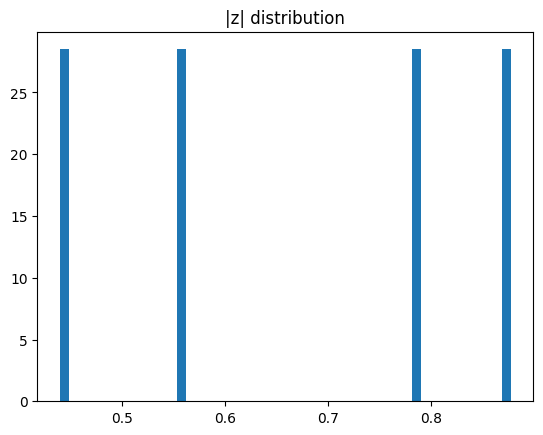

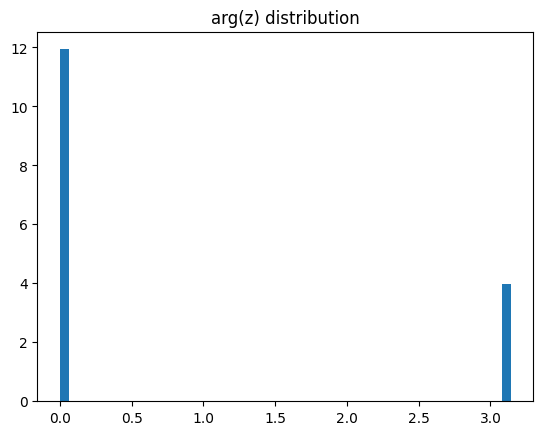

In [41]:
def csr(M): # M is a matrix
    eigenvalues = np.linalg.eigvals(M)
    evals = np.asarray(eigenvalues)

    # Build the 2d complex plane with points
    points = np.column_stack((evals.real, evals.imag))

    tree = cKDTree(points)

    ratios = []

    for i, p in enumerate(points):

        # query 3 nearest neighbors (itself + 2 nearest)
        dist, idx = tree.query(p, k=3)

        # idx[0] is the point itself (distance 0)
        i1, i2, i3 = idx

        lam1 = evals[i1]
        lam2 = evals[i2]
        lam3 = evals[i3]

        # avoid division by zero (rare degeneracy case mentioned in literature)
        denom = (lam3 - lam1)
        if np.abs(denom) < 1e-12:
            continue

        z = (lam2 - lam1) / denom
        ratios.append(z)

    return np.array(ratios)

M = np.array([[1,2,3],
            [3,2,1],
            [22,44,543]])
print(csr(M))

def phase_distribution(M):
    z = csr(M)
    
    
    r = np.abs(z)
    theta = np.angle(z)
    print(f"Distance: {r}", "\n", f"Angle: {theta}")

    plt.hist(r, bins=50, density=True)
    plt.title("|z| distribution")
    plt.show()  

    plt.hist(theta, bins=50, density=True)
    plt.title("arg(z) distribution")
    plt.show()

M = np.array([
    [0.10, 0.20, 0.30, 0.40],
    [0.25, 0.25, 0.25, 0.25],
    [0.50, 0.20, 0.20, 0.10],
    [0.05, 0.15, 0.30, 0.50]])
phase_distribution(M.T)

Distance: [0.93416663 0.60582804 0.99999996 0.99999996 1.         0.81206756
 1.         0.5        0.5        1.        ] 
 Angle: [-0.00000000e+00 -5.28694256e-01 -1.75238781e-08  1.75238781e-08
  1.01909676e-07  0.00000000e+00  5.96328070e-07 -3.57994431e-07
  3.57994431e-07  3.14159194e+00]


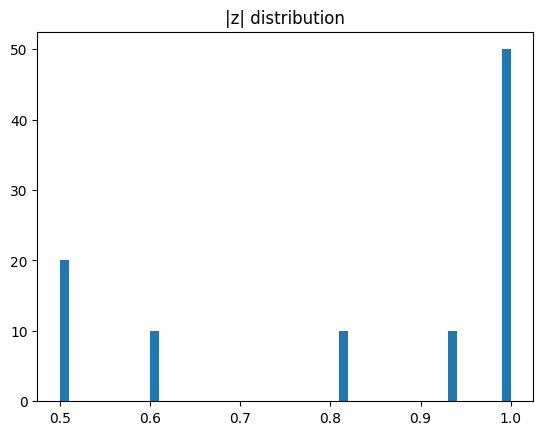

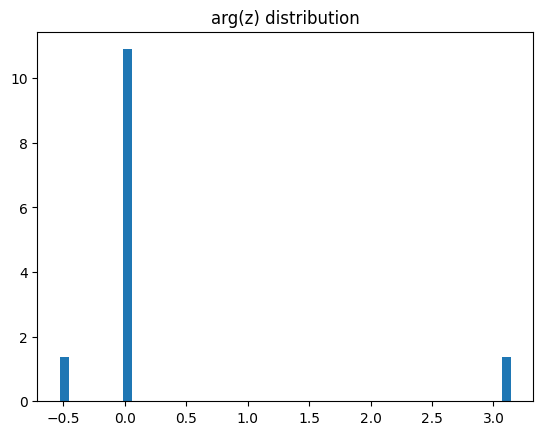

In [42]:


P = np.array([
    [0.05, 0.10, 0.15, 0.05, 0.10, 0.10, 0.10, 0.15, 0.10, 0.20],
    [0.10, 0.05, 0.10, 0.10, 0.10, 0.05, 0.15, 0.10, 0.15, 0.10],
    [0.08, 0.12, 0.05, 0.10, 0.10, 0.10, 0.10, 0.10, 0.15, 0.10],
    [0.10, 0.10, 0.10, 0.05, 0.10, 0.10, 0.10, 0.10, 0.15, 0.10],
    [0.10, 0.10, 0.10, 0.10, 0.05, 0.10, 0.10, 0.10, 0.10, 0.15],
    [0.10, 0.05, 0.10, 0.10, 0.10, 0.10, 0.10, 0.15, 0.10, 0.10],
    [0.10, 0.10, 0.10, 0.10, 0.10, 0.05, 0.10, 0.10, 0.15, 0.10],
    [0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.05, 0.10, 0.10, 0.15],
    [0.15, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.05, 0.10, 0.10],
    [0.10, 0.15, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.05, 0.10]
])

phase_distribution(P)

## Replicating the plots from the paper:
### Plot at the top left:
This plot measures the Poisson density. A given number of points is randomly plotted on 2-d complex space, the z value for each of the points is computed and plotted on a different grid of complex space, this grid is then outputted.

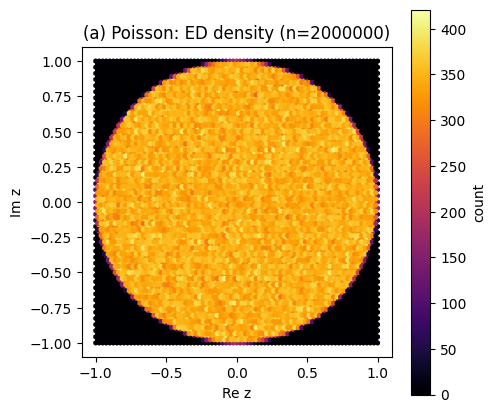

None


In [43]:
def plot_poisson_density(n_pts, box=None):
    if box is None:
        box = 5 * np.sqrt(n_pts)  # keeps mean spacing aprox. 0.2 regardless of n_pts

    pts = np.random.uniform(0, box, size=(n_pts, 2))
    levels = pts[:, 0] + 1j * pts[:, 1]

    points = np.column_stack((levels.real, levels.imag))
    tree = cKDTree(points, boxsize=box)
    _, idx = tree.query(points, k=3)

    lam1 = levels
    lam2 = levels[idx[:, 1]]
    lam3 = levels[idx[:, 2]]

    d_nn, d_nnn = lam2 - lam1, lam3 - lam1
    # minimum-image convention: fix displacements for periodic-wrapped pairs
    d_nn = (d_nn.real - box * np.round(d_nn.real / box)) + \
           1j * (d_nn.imag - box * np.round(d_nn.imag / box))
    d_nnn = (d_nnn.real - box * np.round(d_nnn.real / box)) + \
            1j * (d_nnn.imag - box * np.round(d_nnn.imag / box))

    mask = np.abs(d_nnn) > 1e-12
    z = d_nn[mask] / d_nnn[mask]

    plt.figure(figsize=(5, 5)) # Good settings for a nice output but they could be played with
    plt.hexbin(z.real, z.imag, gridsize=80, extent=(-1, 1, -1, 1), cmap="inferno")
    plt.gca().set_aspect("equal")
    plt.xlabel("Re z"); plt.ylabel("Im z")
    plt.title(f"(a) Poisson: ED density (n={n_pts})")
    plt.colorbar(label="count")
    plt.show()

print(plot_poisson_density(2000000, box=None))


### Plot at the bottom left:
The eigenvalues of a Ginibre matrix are computed and plotted on complex space, their z value is calculated and plotted on another complex grid and this grid is outputted.

A Ginibre matrix is a matrix where its elements are complex numbers that have their real and imaginary coeficients probabilistically chosen from a normal distribution.

This is called the hexbin density of z

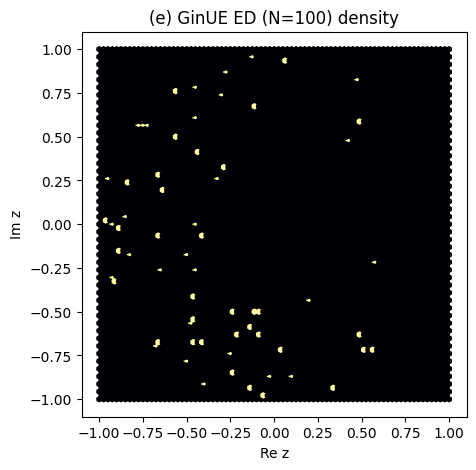

In [44]:
def plot_ginue_density(N):
    G = (np.random.randn(N, N) + 1j*np.random.randn(N, N)) / np.sqrt(2*N)
    evals = np.linalg.eigvals(G)
    points = np.column_stack((evals.real, evals.imag))
    tree = cKDTree(points)

    ratios, origins = [], []
    for lam1, p in zip(evals, points):
        dist, idx = tree.query(p, k=3)
        lam2, lam3 = evals[idx[1]], evals[idx[2]]
        denom = lam3 - lam1
        if np.abs(denom) < 1e-12:
            continue
        ratios.append((lam2 - lam1) / denom)
        origins.append(lam1)

    z = np.array(ratios)
    origins = np.array(origins)
    z = z[np.abs(origins) < 0.8]  # keep bulk eigenvalues, drop edge of the disk

    plt.figure(figsize=(5, 5))
    plt.hexbin(z.real, z.imag, gridsize=80, extent=(-1, 1, -1, 1), cmap="inferno")
    plt.gca().set_aspect("equal")
    plt.xlabel("Re z"); plt.ylabel("Im z")
    plt.title(f"(e) GinUE ED (N={N}) density")
    plt.show()



z = plot_ginue_density(100)  # How to make this bigger

### The top right graph

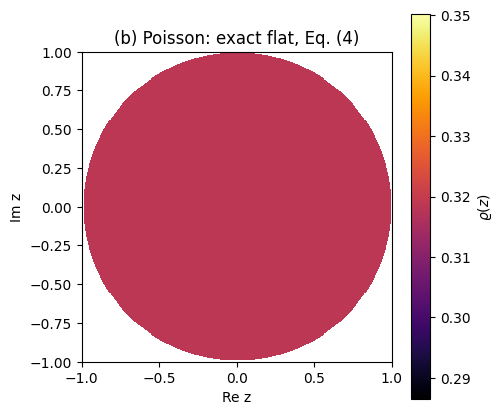

In [45]:
def plot_poisson_theory():
    x = np.linspace(-1, 1, 300)
    y = np.linspace(-1, 1, 300)
    X, Y = np.meshgrid(x, y)
    R = np.hypot(X, Y)
    density = np.where(R <= 1, 1/np.pi, np.nan)

    plt.figure(figsize=(5, 5))
    plt.imshow(density, origin="lower", extent=(-1, 1, -1, 1), cmap="inferno")
    plt.gca().set_aspect("equal")
    plt.xlabel("Re z"); plt.ylabel("Im z")
    plt.title("(b) Poisson: exact flat, Eq. (4)")
    plt.colorbar(label=r"$\varrho(z)$")
    plt.show()

plot_poisson_theory()

### The bottom right graph

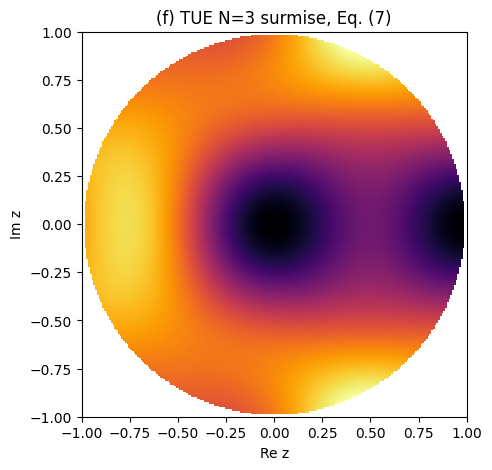

In [46]:
from scipy.interpolate import griddata

def plot_tue3_surmise(n_quad=200, n_grid=150):
    s = np.linspace(-np.pi, np.pi, n_quad)
    S, T = np.meshgrid(s, s, indexing="ij")
    weight = (S**2 + T**2)**2 * (2 - np.cos(S) - np.cos(T))

    def tue3_xy(x, y):
        f2 = 2 - np.cos(S*x - T*y) - np.cos(T*x + S*y)
        f3 = 2 - np.cos(S*(x-1) - T*y) - np.cos(T*(x-1) + S*y)
        integrand = weight * f2 * f3
        return np.trapz(np.trapz(integrand, s, axis=1), s)

    # evaluate on a polar grid, then interpolate to Cartesian for plotting
    rr = np.linspace(1e-3, 0.999, n_grid)
    tt = np.linspace(-np.pi, np.pi, n_grid)
    vals = np.empty((n_grid, n_grid))
    for i, r in enumerate(rr):
        for j, th in enumerate(tt):
            vals[i, j] = tue3_xy(r*np.cos(th), r*np.sin(th))

    norm = np.sum(vals * rr[:, None]) * (rr[1]-rr[0]) * (tt[1]-tt[0])
    dens = vals / norm

    XX = rr[:, None] * np.cos(tt)[None, :]
    YY = rr[:, None] * np.sin(tt)[None, :]

    gx, gy = np.meshgrid(np.linspace(-1, 1, 220), np.linspace(-1, 1, 220))
    grid_vals = griddata((XX.ravel(), YY.ravel()), dens.ravel(), (gx, gy), method="linear")
    grid_vals[gx**2 + gy**2 > 1] = np.nan

    plt.figure(figsize=(5, 5))
    plt.imshow(grid_vals, origin="lower", extent=(-1, 1, -1, 1), cmap="inferno")
    plt.gca().set_aspect("equal")
    plt.xlabel("Re z"); plt.ylabel("Im z")
    plt.title("(f) TUE N=3 surmise, Eq. (7)")
    plt.show()
    return dens

dens = plot_tue3_surmise()

### Plotting this for a stochastic matrix:

In [53]:
def stochastic_density(rule_number, L): 
    G = markov_matrix(rule_number, L)
    
    evals = np.linalg.eigvals(G)
    points = np.column_stack((evals.real, evals.imag))
    tree = cKDTree(points)

    ratios, origins = [], []
    for lam1, p in zip(evals, points):
        dist, idx = tree.query(p, k=3)
        lam2, lam3 = evals[idx[1]], evals[idx[2]]
        denom = lam3 - lam1
        if np.abs(denom) < 1e-12:
            continue
        ratios.append((lam2 - lam1) / denom)
        origins.append(lam1)

    z = np.array(ratios)
    origins = np.array(origins)
    z = z[np.abs(origins) < 0.8]  # keep bulk eigenvalues, drop edge of the disk

    plt.figure(figsize=(5, 5))
    plt.hexbin(z.real, z.imag, gridsize=80, extent=(-1, 1, -1, 1), cmap="inferno")
    plt.gca().set_aspect("equal")
    plt.xlabel("Re z"); plt.ylabel("Im z")
    plt.title(f"(e) GinUE ED (L={L}) density")
    plt.show()

In [54]:
print(stochastic_density(1, 4))

NameError: name 'make_rule' is not defined

## Replicating thses plots for each wolfram class
### Poisson density:

### Ginibre density: 

# Fix the bug on reversed dynamiocs form nitebook 1
# Fix the errors that arised form this bug
# Updte it on the github

# j
# Continue looking at spectral analysis of the matrices, look at ivese atrices and ñroivide a summary to the propertyof transition matrices
# Use matrix inverse for all inversible classicla rules
# specral analysis of these matrices
# explain the coe that gets the matrix 
# j


# plot it for all wolframs classes
# Find a way to classify them if possible





Worked on classicla stocastic matries and did a presnettaion explaining how the code works
Found a way to replicate the plots form the paper

# Literature review:

## Quantum chaology by Michael Berry:

- Discusses how classical quantum systems emerge from quantum mechanics
- Alternative to quantum chaos because chaos can't ocur in quantum systems as it does in classical systems. What we see is the effect of classical chaotic systems on the underlying quantum systems.
- Introduces the field of chaology which explores the quantum signatures of classical chaotic systems.

Paradox highlighted:
- The main paradox that the article approaches is the fact that classical physics is chaotic and arises from quantum mechanics, but quantum mechanics is incapable of producing chaos.

Correspondence principle: 
- There must be a macroscopic enough scale such that quantum and classical mechanics agree.

Main suggestion: Decoherence as the origin of classical chaos
- Quantum decoherence is the loss of coherence in quantum systems due to interactions with the environment.
- Quantum coherence is a characteristic of a given quantum system that occurs when the different possibilities of a different state behave like waves that can then interfere with each other.

## Between order and chaos by James P. Crutchfield:
The main topic in this paper is how to describe a pattern. The paper follows the following thought process:
1. Setup:
- The behaviour of a system lies between being perfectly deterministic (clocks) or completely chaotic / random (like flipping a perfectly random coin).
- In the beggining of the 20th century it is found that simple initial conditions can lead to highly complicated behaviour sensitive to these conditions (chaos theory).

2. Measuring randomness: 
- Within classical information theory, there is a measure for randomness through shannon entropy, but no such concept exists for structure / patterns.
- This paper aims to quantify structure / pattern.

3. Main takeaways:
- Randomness and structure are not oppossites but operate on two separate axis. Entropy rate measures unpredictability and statistical complexity is how much memory a process needs to predict itself.
- KC complexity is the wrong tool for physical structure as it measures hiow hard a single string is to reproduce exactly, which ends up leading to listing random noise as maximum complexity, when it should be the oppossite.
- The epsilon-model describes a whole system, a process and two value swith different meaings. What it measures is how much of the past do you need to know to optimally predict the future. The two values measured are the following scalars:
- - Entropy rate: Irreducible randomness. Randomness left over after extracting every bit of structure.
- - Statistical complexity: How much information a system has to know about its own past to predict its future optimally. Bits of the minimal memory the process needs to carry forward.